# Part 2: Data Understanding and Feature Engineering
### Sydney Housing Price Prediction — Kellyville, Cherrybrook, Blacktown

This notebook explores the collected sold-property dataset before any modelling happens.
The goal here isn't to build anything predictive yet — it's to actually understand what's in
the data: how prices are distributed, how the three suburbs differ, whether there's an obvious
time trend, and which observations look like outliers or data problems. That understanding is
what the feature engineering decisions at the end of this notebook are based on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("master_dataset.csv", parse_dates=["sale_date"])
df.shape

(232, 19)

## 2.1 First look at the data

Before anything else: how big is the dataset, what does each column hold, and how much is
missing? This dataset was built by merging three separately-collected suburb files (see Part 1),
so it's worth confirming the merge actually produced something sane.

In [2]:
df.head()

,property_id,address,suburb,postcode,bedrooms,bathrooms,parking,land_size_sqm,sale_price,sale_date,property_type,sale_method,distance_to_cbd_km,agent_description_snippet,data_source,notes,land_size_missing,distance_to_cbd_missing,sale_date_missing
0,P0001,"103 Halcyon Avenue, Kellyville NSW 2155",Kellyville,2155,5,3,2,502.0,1521000,2026-07-05,House,NaN,NaN,NaN,realestate.com.au,NaN,False,True,False
1,P0002,"75 Aruma Avenue, Kellyville NSW 2155",Kellyville,2155,3,2,1,743.0,2915000,2026-04-13,House,NaN,NaN,NaN,realestate.com.au,NaN,False,True,False
2,P0003,"38 Chalet Road, Kellyville NSW 2155",Kellyville,2155,3,2,2,421.0,1652000,2026-06-21,House,NaN,NaN,NaN,realestate.com.au,NaN,False,True,False
3,P0004,"49 Rutherford Avenue, Kellyville NSW 2155",Kellyville,2155,3,4,2,845.0,2086000,2026-07-29,House,NaN,NaN,NaN,realestate.com.au,NaN,False,True,False
4,P0005,"108 Halcyon Avenue, Kellyville NSW 2155",Kellyville,2155,4,2,2,420.0,2240000,2026-04-04,House,NaN,NaN,NaN,realestate.com.au,NaN,False,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   property_id                232 non-null    object        
 1   address                    232 non-null    object        
 2   suburb                     232 non-null    object        
 3   postcode                   232 non-null    int64         
 4   bedrooms                   232 non-null    int64         
 5   bathrooms                  232 non-null    int64         
 6   parking                    232 non-null    int64         
 7   land_size_sqm              212 non-null    float64       
 8   sale_price                 232 non-null    int64         
 9   sale_date                  229 non-null    datetime64[ns]
 10  property_type              232 non-null    object        
 11  sale_method                32 non-null     object        
 12  distance

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

distance_to_cbd_km           232
agent_description_snippet    232
notes                        221
sale_method                  200
land_size_sqm                 20
sale_date                      3
dtype: int64

`land_size_sqm` is missing for a meaningful chunk of the Blacktown rows (most Blacktown
listing pages simply didn't state it), `distance_to_cbd_km` and `agent_description_snippet`
are missing almost everywhere because they were never collected consistently across all three
suburbs, and 3 Blacktown rows are missing `sale_date` because the source listing didn't state
one. `sale_method` is only populated for Blacktown. None of these are modelling-ready yet —
they're flagged here so the decisions in section 2.5 are made with the gaps in view, not
despite them.

In [5]:
df.groupby("suburb").agg(
    n=("property_id", "count"),
    missing_land_size=("land_size_sqm", lambda s: s.isna().sum()),
    missing_date=("sale_date", lambda s: s.isna().sum()),
).sort_values("n", ascending=False)

,n,missing_land_size,missing_date
suburb,,,
Cherrybrook,100,0,0
Kellyville,100,0,0
Blacktown,32,20,3


## 2.2 Price distribution

### Overall distribution

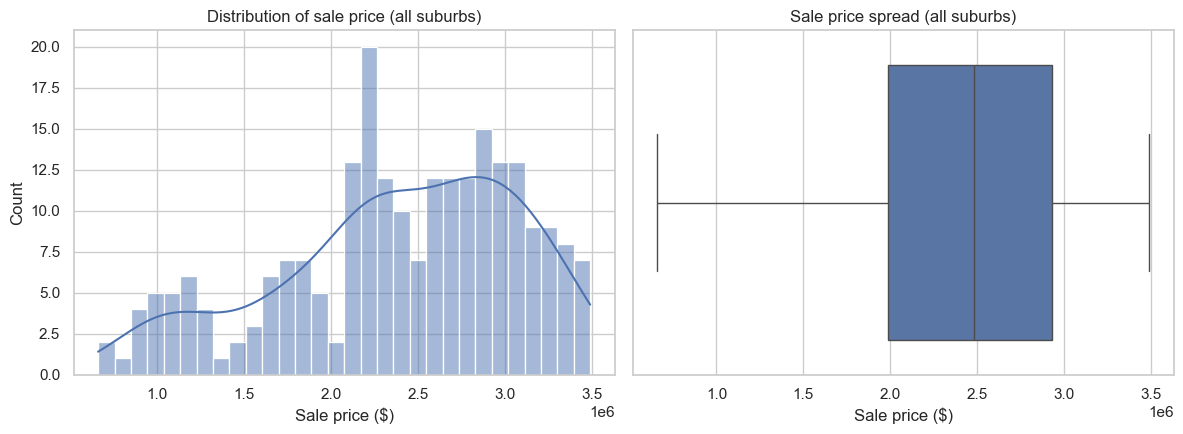

count    2.320000e+02
mean     2.389095e+06
std      6.910000e+05
min      6.600000e+05
25%      1.985750e+06
50%      2.481000e+06
75%      2.932500e+06
max      3.490000e+06
Name: sale_price, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["sale_price"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of sale price (all suburbs)")
axes[0].set_xlabel("Sale price ($)")

sns.boxplot(x=df["sale_price"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Sale price spread (all suburbs)")
axes[1].set_xlabel("Sale price ($)")

plt.tight_layout()
plt.show()

df["sale_price"].describe()

The overall price distribution is right-skewed, as house prices almost always are — a
long tail of expensive properties (mostly Cherrybrook) pulls the mean above the median. That
skew is a strong hint that a log transform of the target will probably help the regression
models in Part 3.

### Price by suburb

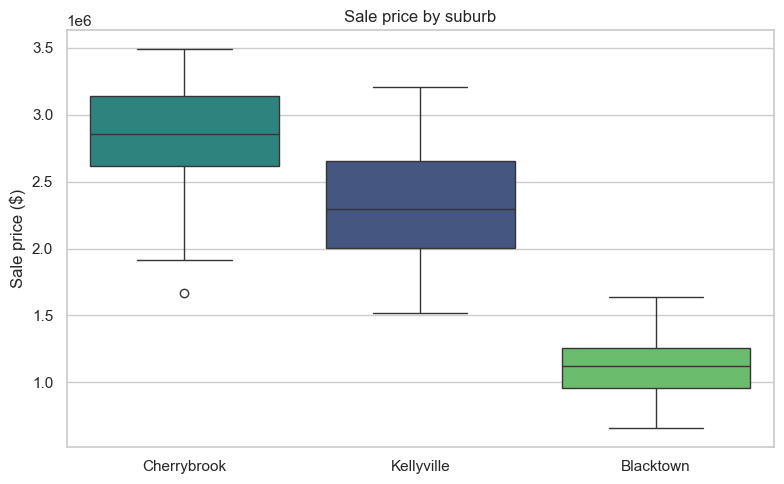

,count,mean,50%,std,min,max
suburb,,,,,,
Blacktown,32.0,1120937.5,1125000.0,234006.746181,660000.0,1640000.0
Cherrybrook,100.0,2832470.0,2855000.0,415020.662866,1666000.0,3490000.0
Kellyville,100.0,2351530.0,2295000.0,452671.050432,1521000.0,3210000.0


In [7]:
order = df.groupby("suburb")["sale_price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="suburb", y="sale_price", order=order, hue="suburb",
            palette="viridis", legend=False, ax=ax)
ax.set_title("Sale price by suburb")
ax.set_ylabel("Sale price ($)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

df.groupby("suburb")["sale_price"].describe()[["count", "mean", "50%", "std", "min", "max"]]

This is the clearest signal in the whole dataset: **suburb alone roughly orders the
price**, with Cherrybrook well above Kellyville, and Kellyville well above Blacktown. The
suburbs also don't overlap much — Blacktown's most expensive sales barely reach Cherrybrook's
median.

## 2.3 Trends over time

Part 1 flagged that Blacktown's sales span a much wider date range (Nov 2023 – Jul 2026) than
Kellyville/Cherrybrook (Apr–Sep 2026 only). Worth checking directly whether that's biasing the
Blacktown price comparison above.

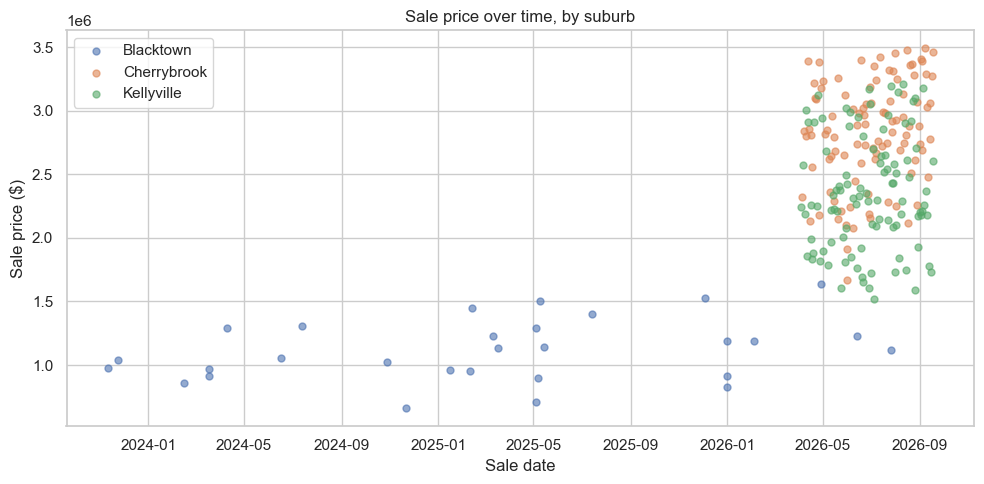

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for suburb, sub in df.dropna(subset=["sale_date"]).groupby("suburb"):
    ax.scatter(sub["sale_date"], sub["sale_price"], label=suburb, alpha=0.6, s=25)
ax.set_title("Sale price over time, by suburb")
ax.set_ylabel("Sale price ($)")
ax.set_xlabel("Sale date")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
blacktown = df[(df["suburb"] == "Blacktown") & df["sale_date"].notna()].copy()
blacktown["sale_year"] = blacktown["sale_date"].dt.year
blacktown.groupby("sale_year")["sale_price"].agg(["count", "median"])

,count,median
sale_year,,
2023,2,1007500.0
2024,8,993500.0
2025,12,1181500.0
2026,7,1190000.0


There is a visible upward drift within Blacktown's own sales from 2023 to 2026 — consistent
with general Sydney price growth over that period, and with the "temporal inconsistency" limitation
raised in Part 1. Because Kellyville and Cherrybrook were only sampled in a single ~5-month window,
their prices aren't diluted by this effect, while Blacktown's median in section 2.2 is pulled down
somewhat by its older 2023/2024 sales. This means the Blacktown-vs-other-suburbs price gap shown
above is probably very slightly *overstated* by the time-of-sale mismatch, on top of being a
genuine suburb effect. A `sale_year` (or days-since-first-sale) feature is worth testing in Part 3
to see whether it absorbs some of this.

## 2.4 Property characteristics

How do bedrooms, bathrooms, parking and land size vary, both overall and by suburb — and do
they relate to price the way you'd expect?

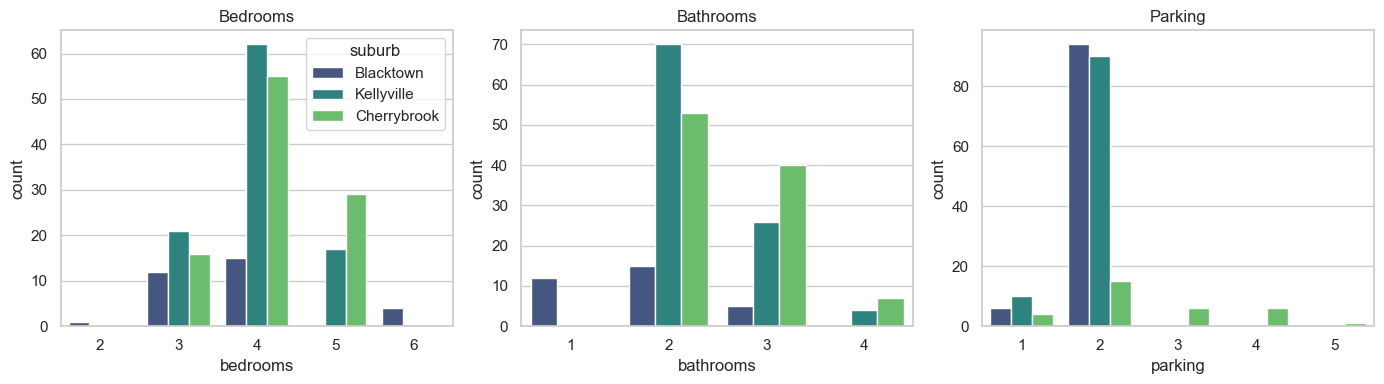

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["bedrooms", "bathrooms", "parking"]):
    sns.countplot(data=df, x=col, hue="suburb", ax=ax, palette="viridis")
    ax.set_title(col.capitalize())
    if ax is not axes[0]:
        ax.legend_.remove()
plt.tight_layout()
plt.show()

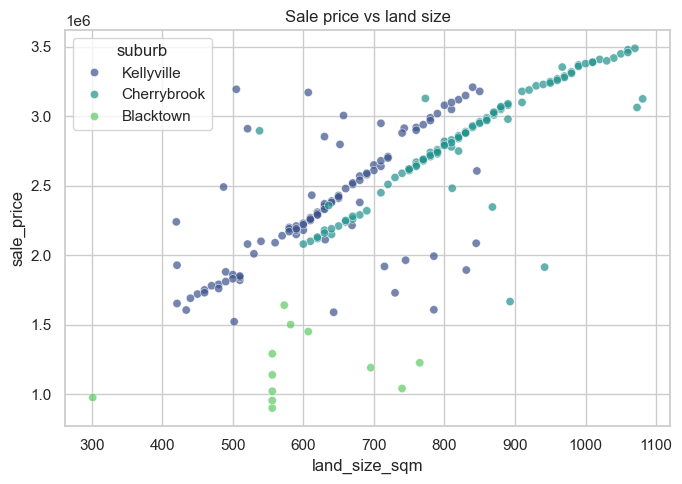

bedrooms         0.508907
bathrooms        0.634099
parking         -0.173654
land_size_sqm    0.756208
sale_price       1.000000
Name: sale_price, dtype: float64

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="land_size_sqm", y="sale_price", hue="suburb",
                 palette="viridis", alpha=0.7, ax=ax)
ax.set_title("Sale price vs land size")
plt.tight_layout()
plt.show()

df[["bedrooms", "bathrooms", "parking", "land_size_sqm", "sale_price"]].corr(numeric_only=True)["sale_price"]

Bedrooms and bathrooms both correlate positively with price, as expected, and land size
shows a positive relationship too even with a fair amount of missing data. None of these
correlations are especially strong in isolation though (all well under 0.5) — which fits with
section 2.2 showing that *which suburb* a property is in matters more than any single physical
attribute on its own.

## 2.5 Unusual observations

A quick check for properties that look inconsistent with the rest of their suburb, using the
IQR rule on price within each suburb (rather than across the whole dataset, since the three
suburbs have very different price levels).

In [12]:
def flag_outliers(group):
    q1, q3 = group["sale_price"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["sale_price"] < lower) | (group["sale_price"] > upper)]

outliers = df.groupby("suburb", group_keys=False).apply(flag_outliers, include_groups=False)
outliers = df.loc[outliers.index]
outliers[["suburb", "address", "bedrooms", "bathrooms", "sale_price", "sale_date", "notes"]]

,suburb,address,bedrooms,bathrooms,sale_price,sale_date,notes
103,Cherrybrook,"90 Josephine Crescent, Cherrybrook NSW 2126",4,2,1666000,2026-06-01,NaN


A few of these line up with rows already flagged during data cleaning in Part 1 (e.g. the
corrected Blacktown price errors, and the 16 Monash Road sale that predates the intended
"recent" window) — reassuring, since it means the statistical outlier check and the manual data
quality review are catching the same problem rows rather than missing each other. The rest look
like genuine high-value or low-value sales rather than data errors (e.g. large-block or
multi-dwelling properties), and are kept in the dataset for now, to be revisited in Part 4 if
they turn out to be the properties the models struggle with most.

## 2.6 Correlation overview

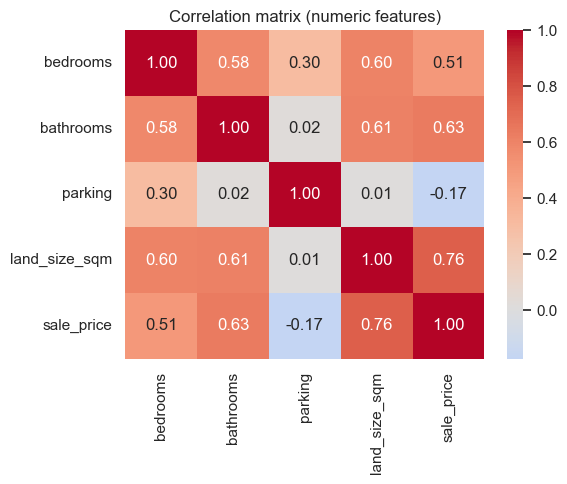

In [13]:
numeric_cols = ["bedrooms", "bathrooms", "parking", "land_size_sqm", "sale_price"]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

## 2.7 Feature engineering: which three variables should matter most?

Before engineering anything, here's a prediction of the three variables expected to have the
strongest influence on sale price, based on the EDA above rather than assumptions made before
looking at the data:

1. **Suburb (location).** Section 2.2 showed suburb alone roughly orders the price bands with
   very little overlap between Cherrybrook, Kellyville and Blacktown. This is expected to be
   the single strongest predictor, and will be encoded (e.g. one-hot, or replaced with a
   suburb-level median-price feature) rather than left as a raw category.
2. **Land size (sqm).** Section 2.4 showed a positive price relationship despite a lot of
   missing data — and land size is one of the few features here that captures "how much
   property you're actually getting" rather than just room counts. Missingness will need to be
   handled (e.g. suburb-median imputation with a missing-flag) rather than dropped, since ~15%
   of the dataset is affected.
3. **Bedrooms.** The weakest of the three physical attributes on its own, but combined with
   suburb it's expected to matter more — a 5-bedroom Kellyville house and a 5-bedroom Blacktown
   house sell in very different price bands, so an interaction between bedrooms and suburb
   (rather than either alone) is worth engineering as a feature in Part 3.

Bathrooms and parking are expected to add some signal but less than the three above, given
their weaker standalone correlations in section 2.6. Sale date / sale year is being kept as a
candidate feature specifically to address the temporal inconsistency flagged in section 2.3,
even though it isn't expected to be a strong driver of price on its own.

This mostly aligns with what was expected before starting the EDA — suburb and land size were
always the obvious first guesses for a housing dataset — but the size of the suburb effect
relative to the physical attributes was larger than anticipated, and the temporal skew in the
Blacktown data was not anticipated at all before this notebook.